In [13]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [14]:
experiment_dir = Path("/dcs/large/u1508153/misdro/normal_bayes_newsvendor")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])


# base_path = "/dcs/large/u1508153/misdro/normal_bayes_newsvendor"

# # load BDRO results and remember to filter (temporary hack for now)
# results_df = pd.read_csv(Path(base_path) / "results.csv", index_col=["uuid", "replication"])
# results_df = results_df.loc[results_df["algorithm"] == "kl_bdro"]

# for setting in ["10000", "10_10", "20_20", "30_30", "50_50"]:
#     experiment_dir = Path(base_path + "_" + setting)
#     assert experiment_dir.exists()
#     df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
#     results_df = pd.concat([results_df, df])

num_total_samples = []
for _, row in results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "our_kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"])
results_df["num_total_samples"] = num_total_samples

results_df

mean_cost     var_cost  \
uuid                                 replication                           
5ddced9f-2180-480b-afb4-2e81b96f909f 0            36.436789   639.420992   
                                     1            33.281338   728.528721   
                                     2            40.117484  1119.197381   
                                     3            34.616122   761.561539   
                                     4            35.734344   528.910402   
...                                                     ...          ...   
d06bf826-7645-474a-a119-fb9d141a14f3 195          33.386982   664.190933   
                                     196          32.442355   318.190697   
                                     197          34.239513   816.237991   
                                     198          27.467649   293.283749   
                                     199          33.335804   420.691479   

                                                   solution  dgp_time  \
uuid                                 replication                        
5ddced9f-2180-480b-afb4-2e81b96f909f 0            32.053977  0.000250   
                                     1            30.624625  0.000474   
                                     2            28.622687  0.000443   
                                     3            33.286875  0.000409   
                                     4            34.235903  0.000531   
...                                                     ...       ...   
d06bf826-7645-474a-a119-fb9d141a14f3 195          17.351119  0.000580   
                                     196          19.583724  0.000717   
                                     197          19.292313  0.000566   
                                     198          16.858261  0.000574   
                                     199          22.836807  0.000581   

                                                  likelihood_time  \
uuid                                 replication                    
5ddced9f-2180-480b-afb4-2e81b96f909f 0                   0.000023   
                                     1                   0.000029   
                                     2                   0.000036   
                                     3                   0.000028   
                                     4                   0.000047   
...                                                           ...   
d06bf826-7645-474a-a119-fb9d141a14f3 195                 0.000200   
                                     196                 0.000210   
                                     197                 0.000197   
                                     198                 0.000197   
                                     199                 0.000199   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
5ddced9f-2180-480b-afb4-2e81b96f909f 0                  0.001556    0.141617   
                                     1                  0.000155    0.037399   
                                     2                  0.000150    0.042387   
                                     3                  0.000161    0.042187   
                                     4                  0.000179    0.053286   
...                                                          ...         ...   
d06bf826-7645-474a-a119-fb9d141a14f3 195                0.000054    8.562795   
                                     196                0.000070    8.225319   
                                     197                0.000053    8.212890   
                                     198                0.000053    8.378197   
                                     199                0.000054    8.047145   

                                                  setup_time    algorithm  \
uuid                                 replication                            
5ddced9f-2180-480b

In [15]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                                                               mean   
algorithm   dgp              epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal           0.05    bayes     normal_gamma 5                     5                       39.340752   
                                                            7                     7                       38.579367   
                                                            10                    10                      38.238413   
                                                            20                    20                      38.050899   
                                                            30                    30                      37.899941   
...                                                                                                             ...   
our_kl_bdro truncated_normal 3.00    bayes     normal_gamma 1                     49                      35.210752   
                                                                                  100                     36.656960   
                                                                                  400                     39.404582   
                                                                                  900                     40.489439   
                                                                                  2500                    41.412107   

                                                                                                                     \
                                                                                                                var   
algorithm   dgp              epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal           0.05    bayes     normal_gamma 5                     5                       33.277351   
                                                            7                     7                       26.111310   
                                                            10                    10                      24.345279   
                                                            20                    20                      21.627086   
                                                            30                    30                      21.299101   
...                                                                                                             ...   
our_kl_bdro truncated_normal 3.00    bayes     normal_gamma 1                     49                      33.634854   
                                                                                  100                     45.783562   
                                                                                  400                     59.764764   
                                                                                  900                     65.130128   
                                                                                  2500                    63.760339   

                                                                                                            var_cost  \
                                                                                                                mean   
algorithm   dgp              epsilon inference posterior    num_posterior_samples num_likelihood_samples               
kl_bdro     normal           0.05    bayes     normal_gamma 5                     5                       870.532525   
                                                            7                     7                       815.538723   
                                                            10                    10                      797.693870   
                                                    

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

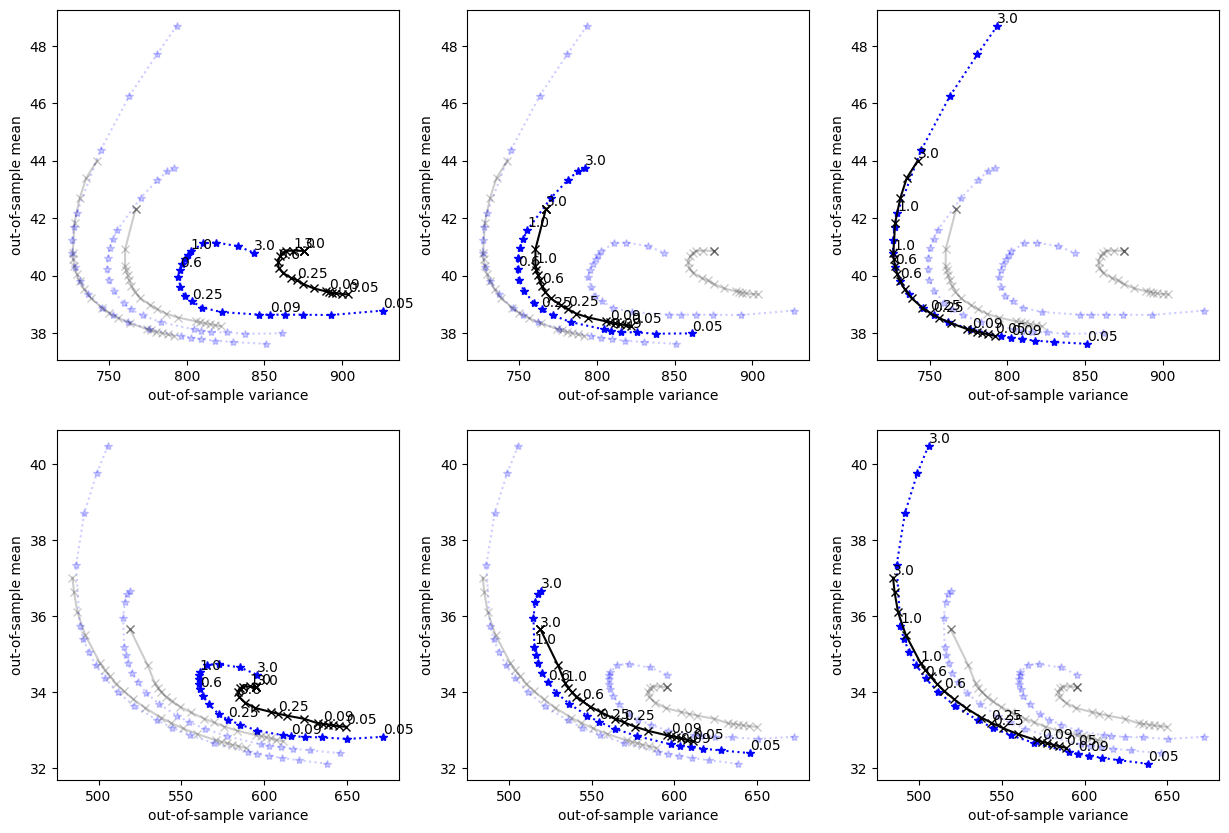

In [26]:
from mis_dro.plot import mean_variance_plot, algorithm_style

from enum import StrEnum

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

compare_col="algorithm"
gb_col="dgp"
ncols=2
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES = [25, 100, 900]

nrows = 2
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(5*ncols, nrows*5))

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)
    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                mean_variance_plot(axes[i, k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled)
            

fig.show()

## Solve time

In [25]:
solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples"]).agg({"solve_time": ["mean"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df

solve_time                                         
                        mean                                         
dgp                   normal             truncated_normal            
algorithm            kl_bdro our_kl_bdro          kl_bdro our_kl_bdro
num_total_samples                                                    
25                  0.012139    0.014874         0.011849    0.015109
49                  0.017590    0.031353         0.017090    0.031256
100                 0.032442    0.026595         0.031273    0.026552
400                 0.120957    0.203859         0.117938    0.186938
900                 0.309346    0.550354         0.305542    0.548508
2500                     NaN    3.372278              NaN    3.347403
10000                    NaN    8.425339              NaN    8.321583

In [18]:
print(solve_time_df.to_latex())

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{4}{r}{solve_time} \\
 & \multicolumn{4}{r}{mean} \\
dgp & \multicolumn{2}{r}{normal} & \multicolumn{2}{r}{truncated_normal} \\
algorithm & kl_bdro & our_kl_bdro & kl_bdro & our_kl_bdro \\
num_total_samples &  &  &  &  \\
\midrule
25 & 0.012139 & 0.014874 & 0.011849 & 0.015109 \\
49 & 0.017590 & 0.031353 & 0.017090 & 0.031256 \\
100 & 0.032442 & 0.026595 & 0.031273 & 0.026552 \\
400 & 0.120957 & 0.203859 & 0.117938 & 0.186938 \\
900 & 0.309346 & 0.550354 & 0.305542 & 0.548508 \\
2500 & NaN & 3.372278 & NaN & 3.347403 \\
10000 & NaN & 8.425339 & NaN & 8.321583 \\
\bottomrule
\end{tabular}



In [19]:
# what is the constant G?
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_kl_bdro_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_kl_bdro_constant("normal_gamma", theta_posterior)

dgp = "normal"
posterior = "normal_gamma"
num_observations = 10
G_constant = []
posterior_expected_kl = []
prior_expected_kl = []
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_kl_bdro_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

(0.08827544585267266, 1.925929944387236e-34)

In [20]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.16462497724528255, 0.012848186395172448)

In [21]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.78569035285864, 0.0)

In [22]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 794.3194647834051, 17.727414116711756)

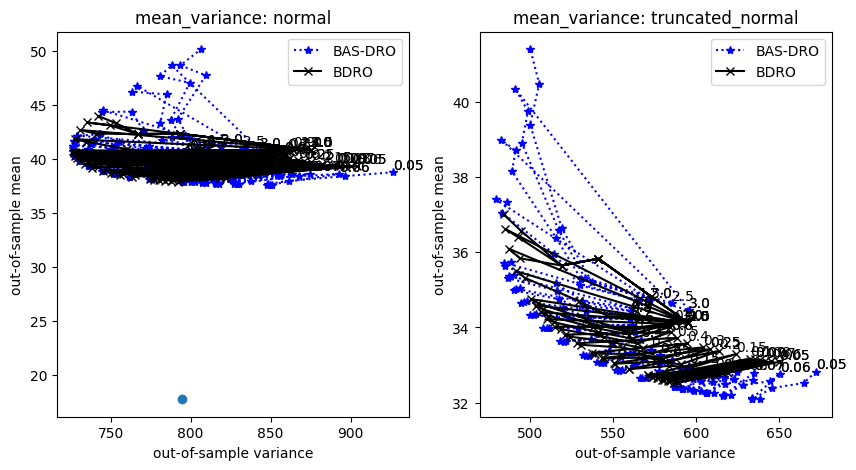

In [23]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
axes[0].scatter(mean_of_variances, var_of_means)
fig.show()

epsilon | mean squared error to opt | std of mean squared error
----------
0.1 | 